In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('benchmark_data/config_yoloRange-20_yoloAngleOfView-0,008_yoloMinConfidence-0,35_gnssConfidenceRangeMultiplier-0,75_odometryPriorWeight-0,5_locationDetectionWeight-1_yoloDetectionWeight-1.csv')
df = df[df['isInsideBorder']]
df['gt-VE_filtered'] = df['gt-VE'].where(df['VE-use-donotuse'] == True)
df.head()

,time,messageTimeInterval,isInsideBorder,detections,gt-GNSS,gt-GNSS-fwd,gt-GNSS-rgt,gt-VE,GNSS-confidence,VE-confidence,VE-use-donotuse,gt-VE_filtered
0,1784031708074417279,23985832,True,0,3.375344,3.298482,-0.716214,3.375344,1.271502,0.953627,True,3.375344
1,1784031708098403111,176037939,True,0,3.377770,3.300720,-0.717341,3.377770,1.271502,0.953627,True,3.377770
2,1784031709102705950,0,True,0,3.382495,3.307524,-0.708209,3.382495,1.269125,1.269125,True,3.382495
3,1784031709974623213,114775710,True,0,3.362802,3.287708,-0.706694,3.362802,1.263101,0.947326,True,3.362802
4,1784031710089398923,0,True,0,3.362759,3.287662,-0.706698,3.362759,1.263101,1.263101,True,3.362759


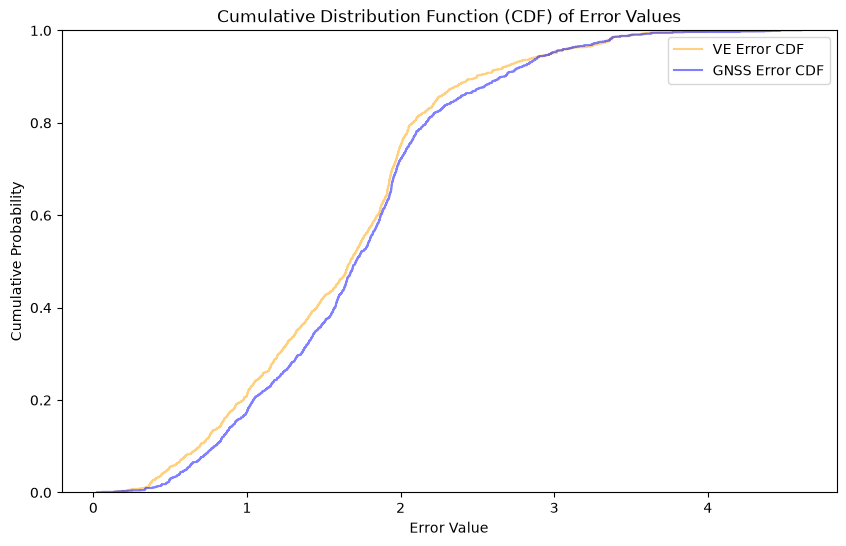

In [3]:
# plot the CDFs for both error values
plt.figure(figsize=(10, 6))
# plt.hist(df['gt-VE_filtered'], bins=100, density=True, cumulative=True, label='VE Error CDF', color='orange', alpha=0.5, histtype='step')
# plt.hist(df['gt-GNSS'], bins=100, density=True, cumulative=True, label='GNSS Error CDF', color='blue', alpha=0.5, histtype='step')
plt.ecdf(df.loc[df['VE-use-donotuse'] == True, 'gt-VE'].dropna(), label='VE Error CDF', color='orange', alpha=0.5)
plt.ecdf(df['gt-GNSS'], label='GNSS Error CDF', color='blue', alpha=0.5)

plt.title('Cumulative Distribution Function (CDF) of Error Values') 
plt.xlabel('Error Value')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

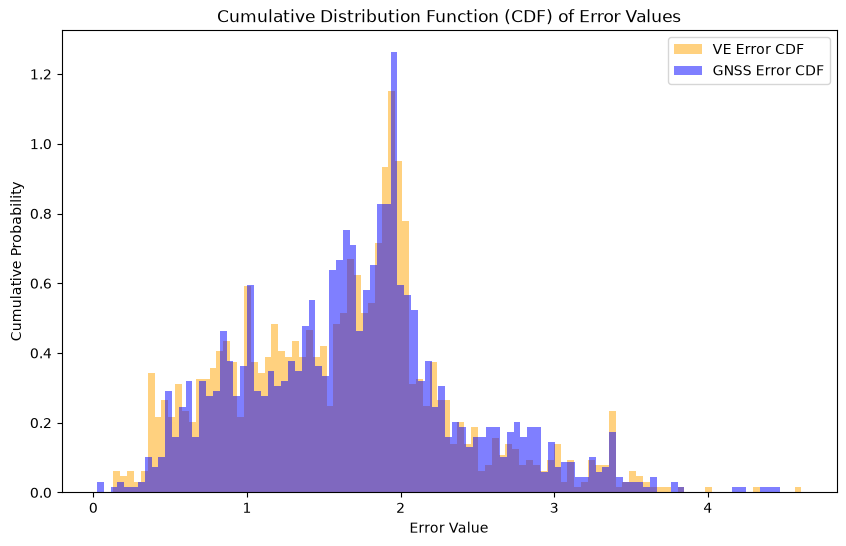

In [4]:
# plot the CDFs for both error values
plt.figure(figsize=(10, 6))
plt.hist(df['gt-VE_filtered'], bins=100, density=True, cumulative=False, label='VE Error CDF', color='orange', alpha=0.5)
plt.hist(df['gt-GNSS'], bins=100, density=True, cumulative=False, label='GNSS Error CDF', color='blue', alpha=0.5)
plt.title('Cumulative Distribution Function (CDF) of Error Values') 
plt.xlabel('Error Value')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

In [5]:
# print percentiles
q1 = df['gt-GNSS'].quantile(0.25)
q2 = df['gt-GNSS'].quantile(0.5)
q3 = df['gt-GNSS'].quantile(0.75)
p9 = df['gt-GNSS'].quantile(0.9)
p95 = df['gt-GNSS'].quantile(0.95)
print(q1)
print(q2)
print(q3)
print(p9)
print(p95)
q1 = df['gt-VE_filtered'].quantile(0.25)
q2 = df['gt-VE_filtered'].quantile(0.5)
q3 = df['gt-VE_filtered'].quantile(0.75)
p9 = df['gt-VE_filtered'].quantile(0.9)
p95 = df['gt-VE_filtered'].quantile(0.95)
print(q1)
print(q2)
print(q3)
print(p9)
print(p95)

1.2094063936981256
1.7095756697625863
2.0529218779604967
2.6618140172059697
2.9768180310170806
1.0890517410383727
1.6733746097947142
1.998476377300313
2.497105586988757
2.9761500056981967
